In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Function
import numpy as np
from torch.cuda.amp import autocast, GradScaler
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Binary Weight Quantizer (STE)
class BinaryWeightQuantizer(Function):
    @staticmethod
    def forward(ctx, input):
        return 2*(input>0).float()-1 #.sign()
    
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone()

# Binary Activation (STE)
class BinaryActivation(Function):
    @staticmethod
    def forward(ctx, input):
        return 2*(input>0).float()-1 # input.sign()
    
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone()

# Binary Conv/Linear Layers for QAT
class QATBinaryConv2d(nn.Conv2d):
    def forward(self, input):
        binary_weight = BinaryWeightQuantizer.apply(self.weight)
        return F.conv2d(input, binary_weight, None, self.stride, self.padding, self.dilation, self.groups)

class QATBinaryLinear(nn.Linear):
    def forward(self, input):
        binary_weight = BinaryWeightQuantizer.apply(self.weight)
        return F.linear(input, binary_weight, self.bias)

def threshold_activation(x, threshold):
    """
    x: torch.Tensor, shape (N, C) or (N, C, H, W)
    threshold: numpy.ndarray, shape (C,)
    """
    th = torch.from_numpy(threshold).to(x.device)

    # Shape broadcast depending on input dimensions
    if x.dim() == 4:
        # (N, C, H, W) → th: (1, C, 1, 1)
        th = th.view(1, -1, 1, 1)
    elif x.dim() == 2:
        # (N, C) → th: (1, C)
        th = th.view(1, -1)
    else:
        raise ValueError(f"Unsupported input shape: {x.shape}")

    return (x > th).float() * 2 - 1

# QAT BNN model 
class QATBNN(nn.Module):
    def __init__(self):
        super(QATBNN, self).__init__()
        self.conv1 = QATBinaryConv2d(1, 16, 3, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = QATBinaryConv2d(16, 32, 3, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = QATBinaryConv2d(32, 32, 3, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(32)

        self.pool = nn.AvgPool2d(2)

        self.bn_fc = nn.BatchNorm1d(3872)  
        self.fc1 = QATBinaryLinear(3872, 10)
        
        self.input_threshold = 0.5

    def forward(self, x):
        x = (x > self.input_threshold).float() * 2 - 1
        
        x = self.conv1(x)
        x = BinaryActivation.apply(x)

        x = self.conv2(x)
        x = BinaryActivation.apply(x)

        x = self.conv3(x)
        x = BinaryActivation.apply(x)

        x = self.pool(x)
        x = BinaryActivation.apply(x) 
        
        x = torch.flatten(x, 1)
        x = self.fc1(x)

        return F.log_softmax(x, dim=1)

In [ ]:
# Data Loaders
batch_size = 1024 
workers = 4
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('data', train=False, transform=transforms.ToTensor()),
    batch_size=batch_size,num_workers=workers)

model = QATBNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

model = model.to(device)
scaler = GradScaler()


torch.backends.cudnn.benchmark = True

conv1_threashold = 0; conv2_threashold = 0; conv3_threashold = 0
train_acc_lst = []; val_acc_lst = []; train_loss_lst = []; val_loss_lst = []

if __name__ == "__main__":
    best_acc = 0
    for epoch in range(100):
        model.train()
        train_loss = 0
        train_correct = 0

        for data, target in train_loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            optimizer.zero_grad()
            with autocast():
                output = model(data)
                loss = F.nll_loss(output, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            train_correct += pred.eq(target).sum().item()
            
        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset) * 100
        train_acc_lst.append(train_acc); train_loss_lst.append(train_loss)

        # Evaluation Loop (float based accuracy)
        model.eval()
        val_loss = 0
        val_correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += F.nll_loss(output, target, reduction='sum').item()
                pred = output.argmax(dim=1)
                val_correct += pred.eq(target).sum().item()

        val_loss /= len(test_loader.dataset)
        val_acc = val_correct / len(test_loader.dataset) * 100
        if val_acc > best_acc:
            best_acc = val_acc
            if best_acc > 94 :
                torch.save(model.state_dict(), "qat_bnn_model_best_lr.pth") 
        val_acc_lst.append(val_acc); val_loss_lst.append(val_loss)

        print(f"Epoch {epoch+1:2d}: Train Loss {train_loss:.4f}, Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | Best Val Acc {best_acc:.2f}%") #Val Loss {val_loss:.4f}, 

    print(f"Best Validation Accuracy: {best_acc:.2f}%")

Epoch  1: Train Loss 45.4692, Acc 35.31% | Val Acc 64.05% | Best Val Acc 64.05%
Epoch  2: Train Loss 13.2166, Acc 71.88% | Val Acc 77.23% | Best Val Acc 77.23%
Epoch  3: Train Loss 9.2345, Acc 79.28% | Val Acc 82.88% | Best Val Acc 82.88%
Epoch  4: Train Loss 7.9412, Acc 81.95% | Val Acc 82.88% | Best Val Acc 82.88%
Epoch  5: Train Loss 6.8304, Acc 84.06% | Val Acc 85.03% | Best Val Acc 85.03%
Epoch  6: Train Loss 5.9428, Acc 85.96% | Val Acc 86.02% | Best Val Acc 86.02%
Epoch  7: Train Loss 5.5011, Acc 86.66% | Val Acc 87.13% | Best Val Acc 87.13%
Epoch  8: Train Loss 5.2248, Acc 87.41% | Val Acc 88.67% | Best Val Acc 88.67%
Epoch  9: Train Loss 5.0138, Acc 87.91% | Val Acc 89.61% | Best Val Acc 89.61%
Epoch 10: Train Loss 4.6954, Acc 88.78% | Val Acc 90.10% | Best Val Acc 90.10%
Epoch 11: Train Loss 4.3137, Acc 89.51% | Val Acc 89.15% | Best Val Acc 90.10%
Epoch 12: Train Loss 4.1886, Acc 89.67% | Val Acc 89.15% | Best Val Acc 90.10%
Epoch 13: Train Loss 4.3745, Acc 89.39% | Val Acc 

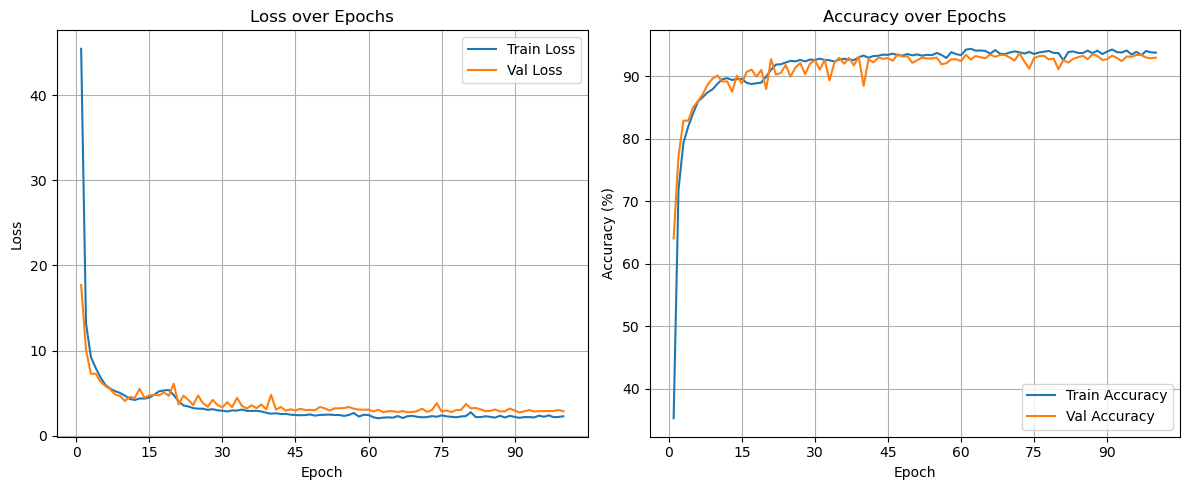

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  

# Epoch list
epochs = range(1, len(train_loss_lst) + 1)

# Draw graphs
plt.figure(figsize=(12, 5))

# 1. Loss graph
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_lst, label='Train Loss')
plt.plot(epochs, val_loss_lst, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  

# 2. Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_lst, label='Train Accuracy')
plt.plot(epochs, val_acc_lst, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  

plt.tight_layout()
plt.show()


In [27]:
#torch.save(model.state_dict(), "qat_bnn_model.pth")
state_dict = torch.load("qat_bnn_model_best.pth")
npy_dict = {
        "conv1w": state_dict["conv1.weight"].sign().cpu().numpy(),
        "conv2w": state_dict["conv2.weight"].sign().cpu().numpy(),
        "conv3w": state_dict["conv3.weight"].sign().cpu().numpy(),
        "fc1w": state_dict["fc1.weight"].sign().cpu().numpy(),
        "fc1b": state_dict["fc1.bias"].cpu().numpy()
    }
np.save("qat_bnn_model_best.npy", npy_dict)

In [117]:
#torch.save(model.state_dict(), "qat_bnn_model.pth")
state_dict = torch.load("qat_bnn_model_best.pth")
npy_dict = {
        "conv1w": (state_dict["conv1.weight"]>0).int().cpu().numpy(),
        "conv2w": (state_dict["conv2.weight"]>0).int().cpu().numpy(),
        "conv3w": (state_dict["conv3.weight"]>0).int().cpu().numpy(),
        "fc1w": (state_dict["fc1.weight"]>0).int().cpu().numpy(),
        "fc1b": (state_dict["fc1.bias"]>0).int().cpu().numpy()
    }
np.save("qat_bnn_model_best01.npy", npy_dict)

In [29]:
weights = np.load("qat_bnn_model_best.npy", allow_pickle=True)
weights.item().keys()

dict_keys(['conv1w', 'conv2w', 'conv3w', 'fc1w', 'fc1b'])

In [30]:
weights.item()['conv1w']

array([[[[ 1.,  1., -1.],
         [ 1., -1., -1.],
         [ 1.,  1.,  1.]]],


       [[[ 1.,  1.,  1.],
         [-1., -1., -1.],
         [ 1.,  1., -1.]]],


       [[[ 1.,  1., -1.],
         [-1.,  1., -1.],
         [-1.,  1.,  1.]]],


       [[[ 1., -1., -1.],
         [-1., -1.,  1.],
         [ 1., -1.,  1.]]],


       [[[-1., -1.,  1.],
         [-1., -1.,  1.],
         [-1.,  1.,  1.]]],


       [[[-1.,  1.,  1.],
         [-1., -1.,  1.],
         [ 1., -1.,  1.]]],


       [[[ 1.,  1., -1.],
         [-1., -1., -1.],
         [-1., -1., -1.]]],


       [[[ 1.,  1.,  1.],
         [-1.,  1.,  1.],
         [-1., -1., -1.]]],


       [[[-1.,  1., -1.],
         [-1.,  1.,  1.],
         [ 1., -1.,  1.]]],


       [[[ 1.,  1.,  1.],
         [ 1.,  1.,  1.],
         [ 1.,  1.,  1.]]],


       [[[ 1., -1.,  1.],
         [-1., -1.,  1.],
         [-1.,  1.,  1.]]],


       [[[-1., -1., -1.],
         [ 1., -1.,  1.],
         [-1.,  1.,  1.]]],


       [[[-1., -

In [31]:
weights.item()

{'conv1w': array([[[[ 1.,  1., -1.],
          [ 1., -1., -1.],
          [ 1.,  1.,  1.]]],
 
 
        [[[ 1.,  1.,  1.],
          [-1., -1., -1.],
          [ 1.,  1., -1.]]],
 
 
        [[[ 1.,  1., -1.],
          [-1.,  1., -1.],
          [-1.,  1.,  1.]]],
 
 
        [[[ 1., -1., -1.],
          [-1., -1.,  1.],
          [ 1., -1.,  1.]]],
 
 
        [[[-1., -1.,  1.],
          [-1., -1.,  1.],
          [-1.,  1.,  1.]]],
 
 
        [[[-1.,  1.,  1.],
          [-1., -1.,  1.],
          [ 1., -1.,  1.]]],
 
 
        [[[ 1.,  1., -1.],
          [-1., -1., -1.],
          [-1., -1., -1.]]],
 
 
        [[[ 1.,  1.,  1.],
          [-1.,  1.,  1.],
          [-1., -1., -1.]]],
 
 
        [[[-1.,  1., -1.],
          [-1.,  1.,  1.],
          [ 1., -1.,  1.]]],
 
 
        [[[ 1.,  1.,  1.],
          [ 1.,  1.,  1.],
          [ 1.,  1.,  1.]]],
 
 
        [[[ 1., -1.,  1.],
          [-1., -1.,  1.],
          [-1.,  1.,  1.]]],
 
 
        [[[-1., -1., -1.],
      

In [ ]:
## run this on pnyq..
## NOTE:: This is a very unoptimized version 
## only use this as a template
import numpy as np
import time
from scipy.signal import convolve2d
from tqdm import trange
mnist = np.load("mnist-original.npy", allow_pickle= True)

X = mnist.item().get("data").T / 255
y = mnist.item().get("label")[0]

weights = np.load('qat_bnn_model_best.npy',allow_pickle=True)

conv1w = weights.item().get('conv1w')
conv2w = weights.item().get('conv2w')
conv3w = weights.item().get('conv3w')
fc3w = weights.item().get('fc1w')
fc3b = weights.item().get('fc1b')

batch_size = 100


def avg_pool2d(x, kernel_size=2, stride=2):
    batch_size, channels, height, width = x.shape

    out_height = height // kernel_size
    out_width = width // kernel_size
    
    x_summed = np.add.reduceat(np.add.reduceat(x, np.arange(0, height, stride), axis=2), 
                               np.arange(0, width, stride), axis=3)
    
    x_pooled = x_summed / (kernel_size * kernel_size)
    
    return x_pooled

def feed_foward(X0):
    ## unfortunately, I found no efficient implementation of 2D Conv without using pytorch 
    ## this code is VERY SLOW. Just use this to see the correctness of the results 
    X0 = 2*(X0>0.5).astype(float) - 1
    X0 = X0.reshape(-1, 1, 28, 28)
    X1 = np.zeros((batch_size, 16, 26, 26))  # Temporary buffer for X1
    X2 = np.zeros((batch_size, 32, 24, 24))  # Temporary buffer for X2
    X3 = np.zeros((batch_size, 32, 22, 22))  # Temporary buffer for X2
    ## conv1 layer
    for b in range(batch_size):
        for co in range(16):
            X1[b,co] = convolve2d(X0[b,0], conv1w[co, 0][::-1, ::-1], mode='valid')

    ## ReLU        
    #X1[X1<0] = 0
    X1 = 2*(X1>0).astype(float) - 1

    ## conv2 layer
    for b in range(batch_size):
        for co in range(32):
            for ci in range(16):
                X2[b,co] += convolve2d(X1[b,ci], conv2w[co, ci][::-1, ::-1], mode='valid')    

    #X2[X2<0] = 0
    X2 = 2*(X2>0).astype(float) - 1


    for b in range(batch_size):
        for co in range(32):
            for ci in range(32):
                X3[b,co] += convolve2d(X2[b,ci], conv3w[co, ci][::-1, ::-1], mode='valid')    

    #X3[X3<0] = 0
    X3 = 2*(X3>0).astype(float) - 1

    A3 = avg_pool2d(X3)
    A3 = 2*(A3>0).astype(float) - 1
    
    A3 = A3.reshape(-1, 3872)
    X3 = np.matmul(A3, fc3w.T) + fc3b

    return X3
            
batch_size = 10

progress_bar = trange(len(X) // batch_size)
correct = 0; total = 0
for idx in progress_bar:
    xs = X[batch_size * idx : batch_size * (idx + 1)]
    ys = y[batch_size * idx : batch_size * (idx + 1)]

    outputs = feed_foward(xs)

    prediction = np.argmax(outputs, axis=1)
    correct += np.sum(prediction == ys)
    total += batch_size

    accuracy = (correct / total) * 100
    progress_bar.set_postfix(accuracy=f"{accuracy:.2f}%")

print(f"Final Accuracy: {accuracy:.2f}%")

100%|██████████| 7000/7000 [31:14<00:00,  3.73it/s, accuracy=94.81%]

Final Accuracy: 94.81%


In [114]:
idx = 6990
xs = X[batch_size * idx : batch_size * (idx + 1)]
ys = y[batch_size * idx : batch_size * (idx + 1)]

outputs = feed_foward(xs)

prediction = np.argmax(outputs, axis=1)
correct += np.sum(prediction == ys)

In [115]:
prediction, ys, np.sum(prediction == ys)

(array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9], dtype=int64),
 array([9., 9., 9., 9., 9., 9., 9., 9., 9., 9.]),
 10)

In [126]:
( 32*24*24) * 10*10**(-9)*70000

12.902400000000002

In [106]:
#xs = X[idx:idx+batch_size]
#ys = y[idx:idx+batch_size]

xs_tensor = torch.tensor(xs, dtype=torch.float32).reshape(-1, 1, 28, 28).to(device)
outputs = model(xs_tensor)
preds = outputs.argmax(dim=1).cpu().numpy()

correct += np.sum(preds == ys)
total += len(ys)

In [109]:
preds

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9], dtype=int64)

In [107]:
model.state_dict()["conv1.weight"][0]

tensor([[[ 1.,  1., -1.],
         [ 1., -1., -1.],
         [ 1.,  1.,  1.]]], device='cuda:0')

In [94]:
preds

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9], dtype=int64)

In [69]:
i=8
outputs[i], np.argmax(outputs[i].cpu()), np.argmax(outputs.cpu(), axis=1)

(tensor([-204.0056, -613.9508, -277.9897, -198.0052, -223.9774, -283.9897,
         -337.9783, -205.9885, -192.0073,    0.0000], device='cuda:0'),
 tensor(9),
 tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 3, 9, 9, 9, 9, 9, 9, 9, 9, 9,
         9, 9, 9, 9, 9, 9, 9, 7, 9, 7, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
         9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 7, 9, 9, 8, 9, 9, 4, 3, 9, 9, 7,
         9, 9, 9, 4, 7, 7, 9, 9, 9, 7, 9, 9, 9, 9, 9, 9, 9, 9, 5, 4, 7, 9, 9, 9,
         9, 9, 9, 9]))

In [ ]:
state_dict = torch.load("qat_bnn_model_best.pth")

for k, v in state_dict.items():
    if "weight" in k and torch.is_tensor(v):
        state_dict[k] = torch.where(v > 0, torch.tensor(1., device=v.device, dtype=v.dtype), torch.tensor(-1., device=v.device, dtype=v.dtype))

torch.save(state_dict, "qat_bnn_model_signed.pth")

In [101]:
model.state_dict()

OrderedDict([('input_threshold', tensor(0.5000, device='cuda:0')),
             ('conv1.weight',
              tensor([[[[ 1.,  1., -1.],
                        [ 1., -1., -1.],
                        [ 1.,  1.,  1.]]],
              
              
                      [[[ 1.,  1.,  1.],
                        [-1., -1., -1.],
                        [ 1.,  1., -1.]]],
              
              
                      [[[ 1.,  1., -1.],
                        [-1.,  1., -1.],
                        [-1.,  1.,  1.]]],
              
              
                      [[[ 1., -1., -1.],
                        [-1., -1.,  1.],
                        [ 1., -1.,  1.]]],
              
              
                      [[[-1., -1.,  1.],
                        [-1., -1.,  1.],
                        [-1.,  1.,  1.]]],
              
              
                      [[[-1.,  1.,  1.],
                        [-1., -1.,  1.],
                        [ 1., -1.,  1.]]],
   

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = QATBNN()
model.load_state_dict(torch.load("qat_bnn_model_signed.pth", map_location=device))

model.eval()
model.to(device)

batch_size = 100
correct = 0
total = 0

with torch.no_grad():
    for idx in range(0, len(X), batch_size):
        xs = X[idx:idx+batch_size]
        ys = y[idx:idx+batch_size]
        
        xs_tensor = torch.tensor(xs, dtype=torch.float32).reshape(-1, 1, 28, 28).to(device)
        outputs = model(xs_tensor)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        correct += np.sum(preds == ys)
        total += len(ys)

print(f"최종 Accuracy: {correct/total*100:.2f}%")

최종 Accuracy: 94.81%


In [119]:
import numpy as np

weights = np.load("qat_bnn_model_best01.npy", allow_pickle=True)
#weights.item().keys()
model_weights = weights.item()

# Function to convert any weight array to C++ style initialization string
def convert_general_conv_weights(arr, var_name, type_name="ap_uint<1>"):
    dims = arr.shape  # Expected: [OUT][IN][3][3]
    if dims[2] != 3 or dims[3] != 3:
        raise ValueError(f"{var_name} shape must be [OUT][IN][3][3], got {dims}")

    cpp_str = f"static const {type_name} {var_name}[{dims[0]}][{dims[1]}][3][3] = {{\n"

    for i in range(dims[0]):  # OUT
        cpp_str += "    {\n"
        for j in range(dims[1]):  # IN
            rows = ", ".join("{" + ", ".join(str(int(arr[i][j][k][l])) for l in range(3)) + "}" for k in range(3))
            cpp_str += f"        {{{rows}}},\n"
        cpp_str += "    },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_array_to_cpp(arr, var_name, type_name="ap_uint<1>"):
    dims = arr.shape
    dim_str = "][".join(str(d) for d in dims)
    cpp_str = f"static const {type_name} {var_name}[{dim_str}] = "

    def recurse(array, indent=1):
        pad = "    " * indent
        if array.ndim == 1:
            return "{" + ", ".join(str(int(x)) for x in array) + "}"
        else:
            return "{\n" + ",\n".join(pad + recurse(sub, indent + 1) for sub in array) + "\n" + "    " * (indent - 1) + "}"

    cpp_str += recurse(arr) + ";\n"
    return cpp_str

# Convert each weight
conv1_cpp = convert_general_conv_weights(model_weights['conv1w'], "conv1_weight")
conv2_cpp = convert_general_conv_weights(model_weights['conv2w'], "conv2_weight")
conv3_cpp = convert_general_conv_weights(model_weights['conv3w'], "conv3_weight")
fc1_cpp = convert_array_to_cpp(model_weights['fc1w'], "fc1_weight")
fc1b_cpp = convert_array_to_cpp(model_weights['fc1b'], "fc1_bias")#, type_name="float")

# Combine all into one header file
full_header_code = (
    "#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n"
    "#include \"params.h\"\n\n"
    f"{conv1_cpp}\n\n"
    f"{conv2_cpp}\n\n"
    f"{conv3_cpp}\n\n"
    f"{fc1_cpp}\n\n"
    f"{fc1b_cpp}\n\n"
    "#endif // WEIGHTS_H\n"
)

# Save to file
full_output_path = "./weights/weights_94.h"
with open(full_output_path, "w") as f:
    f.write(full_header_code)

In [130]:
model_weights['fc1w'].shape

(10, 3872)

In [ ]:
### 1,0 -> 9bit 
import numpy as np

weights = np.load("qat_bnn_model_best01.npy", allow_pickle=True)
model_weights = weights.item()

def pack_3x3_kernel_to_uint9(kernel):
    value = 0
    for i in range(3):
        for j in range(3):
            bit = int(kernel[i][j]) & 0x1
            value |= (bit << (i * 3 + j))
    return value  # int

def convert_conv_weights_to_uint9(weights_arr, var_name):
    out_ch, in_ch, _, _ = weights_arr.shape
    cpp_str = f"static const ap_uint<9> {var_name}[{out_ch}][{in_ch}] = {{\n"

    for o in range(out_ch):
        cpp_str += "    { "
        inner = []
        for i in range(in_ch):
            packed = pack_3x3_kernel_to_uint9(weights_arr[o][i])
            inner.append(f"0b{packed:09b}")
        cpp_str += ", ".join(inner) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_fc_weights_to_uint16(weights_arr, var_name):
    out_ch, in_ch = weights_arr.shape
    num_chunks = (in_ch + 15) // 16 

    cpp_str = f"static const ap_uint<16> {var_name}[{out_ch}][{num_chunks}] = {{\n"

    for o in range(out_ch):
        cpp_str += "    { "
        chunks = []
        for chunk_idx in range(num_chunks):
            packed = 0
            for bit_idx in range(16):
                flat_idx = chunk_idx * 16 + bit_idx
                if flat_idx < in_ch:
                    bit = int(weights_arr[o][flat_idx]) & 0x1
                    packed |= (bit << bit_idx)
            chunks.append(f"0b{packed:016b}")
        cpp_str += ", ".join(chunks) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_array_to_cpp(arr, var_name, type_name="ap_uint<1>"):
    dims = arr.shape
    dim_str = "][".join(str(d) for d in dims)
    cpp_str = f"static const {type_name} {var_name}[{dim_str}] = "

    def recurse(array, indent=1):
        pad = "    " * indent
        if array.ndim == 1:
            return "{" + ", ".join(str(int(x)) for x in array) + "}"
        else:
            return "{\n" + ",\n".join(pad + recurse(sub, indent + 1) for sub in array) + "\n" + "    " * (indent - 1) + "}"

    cpp_str += recurse(arr) + ";\n"
    return cpp_str

conv1_cpp = convert_conv_weights_to_uint9(model_weights['conv1w'], "conv1_weight")
conv2_cpp = convert_conv_weights_to_uint9(model_weights['conv2w'], "conv2_weight")
conv3_cpp = convert_conv_weights_to_uint9(model_weights['conv3w'], "conv3_weight")
fc1_cpp = convert_fc_weights_to_uint16(model_weights['fc1w'], "fc1_weight")

full_header_code = (
    "#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n"
    "#include \"params.h\"\n"
    "#include \"ap_int.h\"\n\n"
    f"{conv1_cpp}\n\n"
    f"{conv2_cpp}\n\n"
    f"{conv3_cpp}\n\n"
    f"{fc1_cpp}\n\n"
    #f"{fc1b_cpp}\n\n"
    "#endif // WEIGHTS_H\n"
)

full_output_path = "./weights/weights_94_packed9.h"
with open(full_output_path, "w") as f:
    f.write(full_header_code)


In [ ]:
### 1,0 -> 9bit 

import numpy as np

weights = np.load("qat_bnn_model_best01.npy", allow_pickle=True)
model_weights = weights.item()

def pack_3x3_kernel_to_uint9(kernel):
    value = 0
    for i in range(3):
        for j in range(3):
            bit = int(kernel[i][j]) & 0x1
            value |= (bit << (i * 3 + j))
    return value  

def convert_conv_weights_to_uint9(weights_arr, var_name):
    out_ch, in_ch, _, _ = weights_arr.shape
    cpp_str = f"static const ap_uint<9> {var_name}[{out_ch}][{in_ch}] = {{\n"

    for o in range(out_ch):
        cpp_str += "    { "
        inner = []
        for i in range(in_ch):
            packed = pack_3x3_kernel_to_uint9(weights_arr[o][i])
            inner.append(f"0b{packed:09b}")
        cpp_str += ", ".join(inner) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_fc_weights_to_uint32_channelwise(weights_arr, var_name):
    fc1w = weights_arr
    out_ch, in_ch = fc1w.shape
    num_ch = 32
    num_pos = 11 * 11  

    assert in_ch == num_ch * num_pos, "input dimensions do not match expected channel"

    cpp_str = f"static const ap_uint<32> {var_name}[{out_ch}][{num_pos}] = {{\n"

    for o in range(out_ch):  
        cpp_str += "    { "
        chunks = []
        for pos in range(num_pos):  
            packed = 0
            for ch in range(num_ch):  
                flat_idx = ch * num_pos + pos 
                bit = int(fc1w[o][flat_idx]) & 0x1
                packed |= (bit << ch)
            chunks.append(f"0x{packed:08x}")
        cpp_str += ", ".join(chunks) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_array_to_cpp(arr, var_name, type_name="ap_uint<1>"):
    dims = arr.shape
    dim_str = "][".join(str(d) for d in dims)
    cpp_str = f"static const {type_name} {var_name}[{dim_str}] = "

    def recurse(array, indent=1):
        pad = "    " * indent
        if array.ndim == 1:
            return "{" + ", ".join(str(int(x)) for x in array) + "}"
        else:
            return "{\n" + ",\n".join(pad + recurse(sub, indent + 1) for sub in array) + "\n" + "    " * (indent - 1) + "}"

    cpp_str += recurse(arr) + ";\n"
    return cpp_str

conv1_cpp = convert_conv_weights_to_uint9(model_weights['conv1w'], "conv1_weight")
conv2_cpp = convert_conv_weights_to_uint9(model_weights['conv2w'], "conv2_weight")
conv3_cpp = convert_conv_weights_to_uint9(model_weights['conv3w'], "conv3_weight")
fc1_cpp = convert_fc_weights_to_uint32_channelwise(model_weights['fc1w'], "fc1_weight")
#fc1b_cpp = convert_array_to_cpp(model_weights['fc1b'], "fc1_bias")  

full_header_code = (
    "#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n"
    "#include \"params.h\"\n"
    "#include \"ap_int.h\"\n\n"
    f"{conv1_cpp}\n\n"
    f"{conv2_cpp}\n\n"
    f"{conv3_cpp}\n\n"
    f"{fc1_cpp}\n\n"
    #f"{fc1b_cpp}\n\n"
    "#endif // WEIGHTS_H\n"
)

full_output_path = "./weights/weights_94_packed9_32.h"
with open(full_output_path, "w") as f:
    f.write(full_header_code)


In [ ]:
### 1,0 -> 9bit 

import numpy as np

weights = np.load("qat_bnn_model_best01.npy", allow_pickle=True)
model_weights = weights.item()

def pack_3x3_kernel_to_uint9(kernel):
    value = 0
    for i in range(3):
        for j in range(3):
            bit = int(kernel[i][j]) & 0x1
            value |= (bit << (i * 3 + j))
    return value  

def convert_conv_weights_to_uint9(weights_arr, var_name):
    out_ch, in_ch, _, _ = weights_arr.shape
    cpp_str = f"static const ap_uint<9> {var_name}[{out_ch}][{in_ch}] = {{\n"

    for o in range(out_ch):
        cpp_str += "    { "
        inner = []
        for i in range(in_ch):
            packed = pack_3x3_kernel_to_uint9(weights_arr[o][i])
            inner.append(f"0b{packed:09b}")
        cpp_str += ", ".join(inner) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_fc_weights_to_uint16_channelwise(weights_arr, var_name):
    fc1w = weights_arr  
    out_ch, in_ch = fc1w.shape
    num_ch = 32
    num_pos = 121  
    group_size = 16
    num_groups = num_ch // group_size  

    cpp_str = f"static const ap_uint<{group_size}> {var_name}[{out_ch}][{num_pos}][{num_groups}] = {{\n"

    for o in range(out_ch):  
        cpp_str += "    {\n"
        for pos in range(num_pos):  
            cpp_str += "        { "
            groups = []
            for g in range(num_groups):  
                packed = 0
                for ch in range(group_size):  
                    ch_idx = g * group_size + ch  
                    flat_idx = ch_idx * num_pos + pos
                    bit = int(fc1w[o][flat_idx]) & 0x1
                    packed |= (bit << ch)
                groups.append(f"0x{packed:04x}")
            cpp_str += ", ".join(groups) + " },\n"
        cpp_str += "    },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_array_to_cpp(arr, var_name, type_name="ap_uint<1>"):
    dims = arr.shape
    dim_str = "][".join(str(d) for d in dims)
    cpp_str = f"static const {type_name} {var_name}[{dim_str}] = "

    def recurse(array, indent=1):
        pad = "    " * indent
        if array.ndim == 1:
            return "{" + ", ".join(str(int(x)) for x in array) + "}"
        else:
            return "{\n" + ",\n".join(pad + recurse(sub, indent + 1) for sub in array) + "\n" + "    " * (indent - 1) + "}"

    cpp_str += recurse(arr) + ";\n"
    return cpp_str

conv1_cpp = convert_conv_weights_to_uint9(model_weights['conv1w'], "conv1_weight")
conv2_cpp = convert_conv_weights_to_uint9(model_weights['conv2w'], "conv2_weight")
conv3_cpp = convert_conv_weights_to_uint9(model_weights['conv3w'], "conv3_weight")
fc1_cpp = convert_fc_weights_to_uint16(model_weights['fc1w'], "fc1_weight")
#fc1b_cpp = convert_array_to_cpp(model_weights['fc1b'], "fc1_bias")  

full_header_code = (
    "#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n"
    "#include \"params.h\"\n"
    "#include \"ap_int.h\"\n\n"
    f"{conv1_cpp}\n\n"
    f"{conv2_cpp}\n\n"
    f"{conv3_cpp}\n\n"
    f"{fc1_cpp}\n\n"
    #f"{fc1b_cpp}\n\n"
    "#endif // WEIGHTS_H\n"
)

full_output_path = "./weights/weights_94_packed9_16.h"
with open(full_output_path, "w") as f:
    f.write(full_header_code)


In [ ]:
import numpy as np

weights = np.load("qat_bnn_model_best01.npy", allow_pickle=True)
model_weights = weights.item()

def pack_3x3_kernel_to_uintX(kernel):
    # kernel shape: [in_ch, 3, 3]
    in_ch, kh, kw = kernel.shape
    packed = [0 for _ in range(9)]  
    for ic in range(in_ch):
        for i in range(3):
            for j in range(3):
                bit = int(kernel[ic][i][j]) & 0x1
                packed[i*3 + j] |= (bit << ic)  
    return packed  

def convert_conv_weights_channel_packed(weights_arr, var_name, in_ch_bits):
    out_ch, in_ch, _, _ = weights_arr.shape
    cpp_str = f"static const ap_uint<{in_ch_bits}> {var_name}[{out_ch}][9] = {{\n"
    for o in range(out_ch):
        packed = pack_3x3_kernel_to_uintX(weights_arr[o])
        cpp_str += "    { " + ", ".join(f"0x{p:0{in_ch_bits//4}x}" for p in packed) + " },\n"
    cpp_str += "};\n"
    return cpp_str

def convert_fc_weights_to_uint32_channelwise(weights_arr, var_name):
    # fc1w shape: (OUT_CH, IN_CH) = (10, 3872)
    fc1w = weights_arr
    out_ch, in_ch = fc1w.shape
    num_ch = 32
    num_pos = 11 * 11  # 121

    assert in_ch == num_ch * num_pos, "input dimensions do not match expected channel"

    cpp_str = f"static const ap_uint<{num_ch}> {var_name}[{out_ch}][{num_pos}] = {{\n"

    for o in range(out_ch):
        cpp_str += "    { "
        chunks = []
        for pos in range(num_pos):  
            packed = 0
            for ch in range(num_ch):  
                flat_idx = ch * num_pos + pos  #
                bit = int(fc1w[o][flat_idx]) & 0x1
                packed |= (bit << ch)
            chunks.append(f"0x{packed:08x}")
        cpp_str += ", ".join(chunks) + " },\n"
    cpp_str += "};\n"
    return cpp_str

conv1_cpp = convert_conv_weights_channel_packed(model_weights['conv1w'], "conv1_weight", 1)     
conv2_cpp = convert_conv_weights_channel_packed(model_weights['conv2w'], "conv2_weight", 16)   
conv3_cpp = convert_conv_weights_channel_packed(model_weights['conv3w'], "conv3_weight", 32)  
fc1_cpp   = convert_fc_weights_to_uint32_channelwise(model_weights['fc1w'], "fc1_weight")          

full_header_code = (
    "#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n"
    "#include \"params.h\"\n"
    "#include \"ap_int.h\"\n\n"
    f"{conv1_cpp}\n\n"
    f"{conv2_cpp}\n\n"
    f"{conv3_cpp}\n\n"
    f"{fc1_cpp}\n\n"
    "#endif // WEIGHTS_H\n"
)

full_output_path = "./weights/weights_94_packed_channel.h"
with open(full_output_path, "w") as f:
    f.write(full_header_code)

print("Packing complete. File saved to", full_output_path)

Packing complete. File saved to ./weights/weights_94_packed_channel.h
